# Microgrid pipeline — Excel-driven
Runs the full chain: generate `inputs.xlsx` -> inspect the loader -> solve & build BOM -> sanity check.

Requires `openpyxl` (already installed). Use the **Python 3.13 (PHOTONS)** kernel.

## 1. excel_loader — parse inputs.xlsx


Peek at the raw sheets (handy while editing the workbook):

In [1]:
import importlib
import excel_loader
importlib.reload(excel_loader)   # pick up any edits to excel_loader.py without restarting
from excel_loader import load_inputs

# Read from the Google Sheet (excel_loader.DEFAULT_SOURCE). Do NOT pass "inputs.xlsx" here,
# or it reads the stale local file instead of the live Sheet.
print("source:", excel_loader.DEFAULT_SOURCE)
inputs = load_inputs()
print(f"panel    = {inputs.panel['name']}  ({inputs.panel['rating_W']} W)")
print(f"battery  = {inputs.battery['name']}  ({inputs.battery['module_kWh']} kWh/module)")
print(f"inverter = {inputs.inverter['name']}  ({inputs.inverter['rating_kW']} kW)")
print(f"effective solar  cost_per_kW  = {inputs.eff_solar_cost_per_kW:,.1f} $/kW  (panel+inverter+per_kW BOS {inputs.per_kw_solar:.1f})")
print(f"effective battery cost_per_kWh = {inputs.eff_battery_cost_per_kWh:,.1f} $/kWh  (battery+per_kWh BOS {inputs.per_kwh_batt:.1f})")
print(f"fixed_cost = {inputs.fixed_cost:,.1f} $   derate = {inputs.derate:.4f}")

source: https://docs.google.com/spreadsheets/d/1Crre-82kURC6sVCwFSJgN03BnGRC3EOMqF8pgb8Q-O0/edit?gid=957556041#gid=957556041
panel    = JinkoTiger  (550 W)
battery  = Pylontech_US5000  (4.8 kWh/module)
inverter = SMA_STP50  (50 kW)
effective solar  cost_per_kW  = 450.0 $/kW  (panel+inverter+per_kW BOS 140.0)
effective battery cost_per_kWh = 375.0 $/kWh  (battery+per_kWh BOS 8.0)
fixed_cost = 13,500.0 $   derate = 0.8820


## 1b. Exactly what goes into the solver\n\nBuilds the precise `SimpleNamespace` passed to `optimize_microgrid(...)` (via `build_optimizer_input`) and prints every field. Big structures (`df`, `f_l_t`) are summarized so it doesn't dump 8760 rows.

In [2]:
import importlib
import numpy as np, pandas as pd
import run_microgrid, excel_loader
importlib.reload(excel_loader); importlib.reload(run_microgrid)

T = run_microgrid.T  # 8760

# Build the SAME inputs the solver receives
df = run_microgrid.build_df(inputs, T)
ns = excel_loader.build_optimizer_input(inputs, df, T)

def hr(t):
    print("\n" + "=" * 72); print(t); print("=" * 72)

def show(title, specs):
    hr(title); print(pd.DataFrame(specs).T.to_string())

hr("SETS");    [print(f"  {k:14s}: {v}") for k, v in ns.sets.items()]
hr("SUBSETS"); [print(f"  {k:26s}: {v}") for k, v in ns.subsets.items()]

hr("SCALARS")
print("num_timesteps  :", ns.num_timesteps)
print("grid_cut_hours :", ns.grid_cut_hours)
print("grid_specs     :", ns.grid_specs)
print("fuel_burn_rates:", ns.fuel_burn_rates)
print("project_specs  :")
for k, v in ns.project_specs.items():
    print(f"    {k:18s}: {v}")

show("tech_specs",    ns.tech_specs)
show("storage_specs", ns.storage_specs)
show("tank_specs",    ns.tank_specs)
show("fuel_specs",    ns.fuel_specs)

hr(f"df  (shape {ns.df.shape})  — the hourly time series")
print("columns:", list(ns.df.columns))
print(ns.df.head(6).to_string())
load = ns.df["total_energy_demand"]; gi = ns.df["G(i)"]
print(f"\nLOAD  kWh/h : min={load.min():.2f}  mean={load.mean():.2f}  max={load.max():.2f}  annual={load.sum():,.0f}")
print(f"G(i) (GHI)  : min={gi.min():.4f}  mean={gi.mean():.4f}  max={gi.max():.4f}")
print(f"tariff      : {ns.df['tariff'].iloc[0]}  (constant grid price $/kWh)")

hr("f_l_t  (availability factor per technology per hour = GHI * derate for solar)")
techs = sorted({k[0] for k in ns.f_l_t})
for t in techs:
    arr = np.array([ns.f_l_t[(t, hh)] for hh in range(ns.num_timesteps)])
    print(f"  {t:8s}: n={len(arr)}  min={arr.min():.4f}  mean={arr.mean():.4f}  max={arr.max():.4f}")
    print(f"            hours 6-13: {np.round(arr[6:14], 4)}")
print(f"\n(derate folded into f_l_t = {inputs.derate:.4f}; GHI column above is pre-derate)")

latlong -3.314732 37.326358

SETS
  technologies  : ['solar', 'diesel']
  batteries     : ['li']
  fuels         : ['diesel_fuel']

SUBSETS
  purchasing_fuels          : ['diesel_fuel']
  fuel_technologies         : ['diesel']
  producing_technologies    : ['solar', 'diesel']
  fuel_consuming_technologies: ['diesel']
  fuel_creating_technologies: []
  diesel_technologies       : ['diesel']

SCALARS
num_timesteps  : 8760
grid_cut_hours : []
grid_specs     : {'grid_capacity': 10000.0}
fuel_burn_rates: {('diesel', 'diesel_fuel'): 2.857142857142857}
project_specs  :
    lifetime          : 20
    fixed_cost        : 13500.0
    resiliency_days   : 0
    day_hours         : 24.0
    offgrid           : False
    offgrid_base      : False
    max_diesel        : 0.5
    max_grid_fraction : 0.0

tech_specs
        size  min_output  max_output  cost_per_kW  maintenance_per_kW  existing_rating  lifetime  efficiency  module_capacity
solar    NaN         0.0     10000.0        450.0              

## 2. run_microgrid — solve + bill of materials
Solves the full 8760-hour year (~tens of seconds), writes `solution.csv` and `bom.csv`, and prints the summary + reconciliation.

In [3]:
import importlib
import run_microgrid
importlib.reload(run_microgrid)   # pick up edits to run_microgrid.py
run_microgrid.main()

latlong -3.314732 37.326358
Optimal solution found! All constraints satisfied and objective gap is within tolerance.
Status HighsModelStatus.kOptimal in 37.1s
  solar    1718.6 kW   battery    2282.6 kWh
  diesel      75.4 kW
  LCoE  $0.0952/kWh   CapEx $1,642,816
  BOM reconciliation drift $0.00 -> OK
  wrote solution.csv, bom.csv


Inspect the written outputs:

In [4]:
import pandas as pd
bom = pd.read_csv("bom.csv")
display(bom)

sol = pd.read_csv("solution.csv")
print("solution.csv shape:", sol.shape)
display(sol.head(14))

,section,item,qty,unit_cost,extended_cost,notes
0,component,PV module: JinkoTiger,3125.0,137.4860,429643.88,550 W each
1,component,Inverter: SMA_STP50,18.0,5728.5851,103114.53,"50 kW each; sized 859 kW = max(0.5*solar, load)"
2,component,Battery module: Pylontech_US5000,476.0,1759.8674,837696.89,4.8 kWh each
3,bos_per_kW,DC cabling,1.0,35.0000,60150.14,DC cable per installed kW
4,bos_per_kW,Mounting structure,1.0,60.0000,103114.53,racking per kW
5,bos_per_kW,Install labor,1.0,45.0000,77335.90,labor per kW
6,bos_per_kWh,Battery DC wiring,1.0,8.0000,18260.42,per kWh
7,bos_fixed,AC protections,1.0,4000.0000,4000.00,breakers / SPD
8,bos_fixed,Engineering+permits,1.0,6000.0000,6000.00,design & permits
9,bos_fixed,Transport,700.0,5.0000,3500.00,"unit_cost = $/km, qty = km"


solution.csv shape: (8760, 11)


,Power Purchased,State Of Charge - li,solar to li,diesel to li,Solar to li,Power Output - solar,Power Output - diesel,diesel_fuel_burned_diesel,li to Load,GHI,LOAD
0,0.0,2232.552844,0.000000,0.0,0.000000,0.000000,-0.0,-0.0,50.000000,0.000,50.0
1,0.0,2182.552844,0.000000,0.0,0.000000,0.000000,-0.0,-0.0,50.000000,0.000,50.0
2,0.0,2132.552844,0.000000,0.0,0.000000,0.000000,-0.0,-0.0,50.000000,0.000,50.0
3,0.0,2082.552844,0.000000,0.0,0.000000,0.000000,-0.0,-0.0,50.000000,0.000,50.0
4,0.0,2053.773814,0.000000,0.0,0.000000,21.220971,-0.0,-0.0,28.779029,0.014,50.0
5,0.0,2053.773814,0.000000,0.0,0.000000,60.000000,-0.0,-0.0,0.000000,0.073,60.0
6,0.0,2053.773814,0.000000,0.0,0.000000,120.000000,-0.0,-0.0,0.000000,0.343,120.0
7,0.0,2053.773814,0.000000,0.0,0.000000,200.000000,-0.0,-0.0,0.000000,0.663,200.0
8,0.0,2053.773814,0.000000,0.0,0.000000,260.000000,0.0,0.0,0.000000,0.763,260.0
9,0.0,2053.773814,0.000000,0.0,0.000000,300.000000,0.0,0.0,0.000000,0.785,300.0


In [5]:

sol.describe()


,Power Purchased,State Of Charge - li,solar to li,diesel to li,Solar to li,Power Output - solar,Power Output - diesel,diesel_fuel_burned_diesel,li to Load,GHI,LOAD
count,8760.0,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,0.0,954.938871,75.726282,0.065944,75.726282,180.043894,3.953932,11.296948,72.211067,0.234860,180.416667
std,0.0,575.396214,206.146477,1.735942,206.146477,294.485860,14.692765,41.979328,96.647821,0.332675,112.644462
min,0.0,456.510569,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000
25%,0.0,456.510569,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,57.500000
50%,0.0,706.510569,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,175.000000
75%,0.0,1336.510569,0.000000,0.000000,0.000000,260.000000,0.000000,0.000000,120.000000,0.455000,300.000000
max,0.0,2282.552844,1141.276422,75.359801,1141.276422,1441.276422,75.359801,215.313718,355.452649,1.114000,360.000000


## 4. Reports — sizing & cost, BOM, energy mix, independence\n\nSolves once and produces: a technology sizing/cost table (panels priced **without** the inverter, which is its own line), the bill of materials, an energy-by-source chart grouping **solar + battery**, and the **energy-independence %** (share of load not served by the grid).

In [6]:
import importlib
import run_microgrid, reporting
importlib.reload(run_microgrid); importlib.reload(reporting)

inputs, solution_data, solution_df, status = run_microgrid.solve()   # full-year solve
print("status:", status)

print("\nTECHNOLOGY SIZE & COST  (panels exclude inverter; inverter is its own line)")
display(reporting.cost_table(inputs, solution_data))

print("LCoE & MONTHLY PAYMENT")
display(reporting.lcoe_table(solution_data))

print("BILL OF MATERIALS")
display(reporting.bom_table(inputs, solution_data))

latlong -3.314732 37.326358
Optimal solution found! All constraints satisfied and objective gap is within tolerance.
status: HighsModelStatus.kOptimal

TECHNOLOGY SIZE & COST  (panels exclude inverter; inverter is its own line)


,Technology,Size,Unit,Cost_$
0,Solar panels,1718.6,kW,429644.0
1,Inverter,859.3,kW,103115.0
2,Battery,2282.6,kWh,837697.0
3,Diesel generator,75.4,kW,7536.0
4,TOTAL,,,1377992.0


LCoE & MONTHLY PAYMENT


,Metric,Value,Unit
0,LCoE,9.520000e-02,$/kWh
1,Annual energy served,1.580450e+06,kWh
2,Annual cost,1.505230e+05,$
3,Monthly payment,1.254400e+04,$/month


BILL OF MATERIALS


,section,item,qty,unit_cost,extended_cost,notes
0,component,PV module: JinkoTiger,3125,137.486,429643.88,550 W each
1,component,Inverter: SMA_STP50,18,5728.5851,103114.53,"50 kW each; sized 859 kW = max(0.5*solar, load)"
2,component,Battery module: Pylontech_US5000,476,1759.8674,837696.89,4.8 kWh each
3,bos_per_kW,DC cabling,1.0,35.0,60150.14,DC cable per installed kW
4,bos_per_kW,Mounting structure,1.0,60.0,103114.53,racking per kW
5,bos_per_kW,Install labor,1.0,45.0,77335.90,labor per kW
6,bos_per_kWh,Battery DC wiring,1.0,8.0,18260.42,per kWh
7,bos_fixed,AC protections,1.0,4000.0,4000.00,breakers / SPD
8,bos_fixed,Engineering+permits,1.0,6000.0,6000.00,design & permits
9,bos_fixed,Transport,700.0,5.0,3500.00,"unit_cost = $/km, qty = km"


ENERGY INDEPENDENCE: 100.0 %   (grid 0 kWh of 1,580,450 kWh load)
  solar 1,577,185 kWh   diesel 34,636 kWh   grid 0 kWh


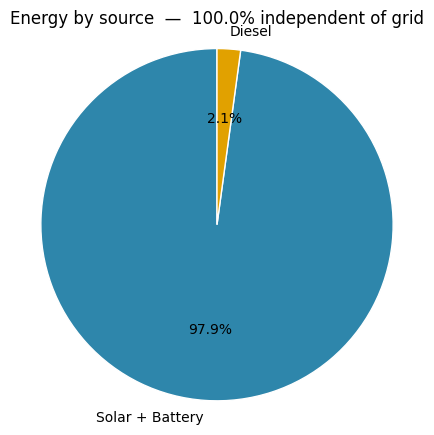

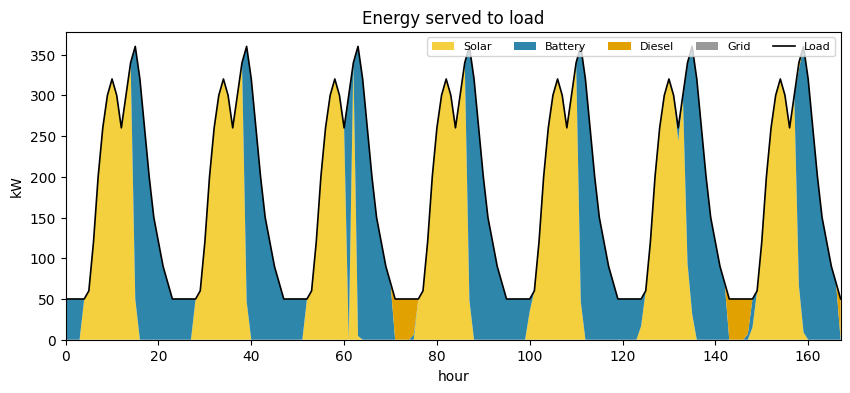

In [7]:
es = reporting.energy_summary(solution_df)
print(f"ENERGY INDEPENDENCE: {es['energy_independence_pct']:.1f} %   "
      f"(grid {es['grid_kWh']:,.0f} kWh of {es['load_kWh']:,.0f} kWh load)")
print(f"  solar {es['solar_kWh']:,.0f} kWh   diesel {es['diesel_kWh']:,.0f} kWh   grid {es['grid_kWh']:,.0f} kWh")

reporting.plot_energy_by_source(solution_df)       # pie
reporting.plot_dispatch(solution_df, week=21)      # week 21
import matplotlib.pyplot as plt; plt.show()

## 3. sanity_check — design-rule demonstration
Edits temp copies of the workbook and re-solves to show that a **per_kW** cost change moves sizing while a **fixed** cost change only moves LCoE. Runs 3 full-year solves (~1 min). `SystemExit` is caught so the kernel stays alive.

In [8]:
import pandas as pd
import plotly.graph_objects as go

fig = go.Figure()

for col in sol.columns:
    if pd.api.types.is_numeric_dtype(sol[col]):
        fig.add_trace(go.Scatter(x=sol.index, y=sol[col], name=col, mode='lines'))

fig.update_layout(title='Solution', hovermode='x unified', height=600)
fig.show()